In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

import smarts_cerebellum.globals as gl


In [2]:
# all regions

"""
array(['Left_I_IV', 'Right_I_IV', 'Left_V', 'Right_V', 'Left_VI',
       'Vermis_VI', 'Right_VI', 'Left_CrusI', 'Vermis_CrusI',
       'Right_CrusI', 'Left_CrusII', 'Vermis_CrusII', 'Right_CrusII',
       'Left_VIIb', 'Vermis_VIIb', 'Right_VIIb', 'Left_VIIIa',
       'Vermis_VIIIa', 'Right_VIIIa', 'Left_VIIIb', 'Vermis_VIIIb',
       'Right_VIIIb', 'Left_IX', 'Vermis_IX', 'Right_IX', 'Left_X',
       'Vermis_X', 'Right_X', 'Left_Dentate', 'Right_Dentate',
       'Left_Interposed', 'Right_Interposed', 'Left_Fastigial',
       'Right_Fastigial'], dtype=object)
"""

"\narray(['Left_I_IV', 'Right_I_IV', 'Left_V', 'Right_V', 'Left_VI',\n       'Vermis_VI', 'Right_VI', 'Left_CrusI', 'Vermis_CrusI',\n       'Right_CrusI', 'Left_CrusII', 'Vermis_CrusII', 'Right_CrusII',\n       'Left_VIIb', 'Vermis_VIIb', 'Right_VIIb', 'Left_VIIIa',\n       'Vermis_VIIIa', 'Right_VIIIa', 'Left_VIIIb', 'Vermis_VIIIb',\n       'Right_VIIIb', 'Left_IX', 'Vermis_IX', 'Right_IX', 'Left_X',\n       'Vermis_X', 'Right_X', 'Left_Dentate', 'Right_Dentate',\n       'Left_Interposed', 'Right_Interposed', 'Left_Fastigial',\n       'Right_Fastigial'], dtype=object)\n"

In [3]:
regions = ['Left_Dentate', 'Right_Dentate',
       'Left_Interposed', 'Right_Interposed', 'Left_Fastigial',
       'Right_Fastigial']

reds = sns.color_palette("Reds", n_colors=len(regions))
red_purples = sns.color_palette("RdPu", n_colors = len(regions))
blues = sns.color_palette("Blues", n_colors=len(regions))
blue_purples = sns.color_palette("PuBu", n_colors = len(regions))

## Modulated GM volume

convergence warnings

In [4]:
# currently avaialble: 'GM_mod', 'T1'
segment = 'GM'

patients_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_patients_MNISymC_Diedrichsen_2009_{segment}_mod_mean.tsv'), sep = '\t')
controls_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_controls_MNISymC_Diedrichsen_2009_{segment}_mod_mean.tsv'), sep = '\t')

patients_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'patients_MNISymC_{segment}_mod_Diedrichsen_2009_lme.tsv'), sep = '\t')
controls_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'controls_MNISymC_{segment}_mod_Diedrichsen_2009_lme.tsv'), sep = '\t')


patients_lme = patients_lme[patients_lme.regionname.isin(regions)]
controls_lme = controls_lme[controls_lme.regionname.isin(regions)]

patients_actual = patients_actual[patients_actual.regionname.isin(regions)]
controls_actual = controls_actual[controls_actual.regionname.isin(regions)]

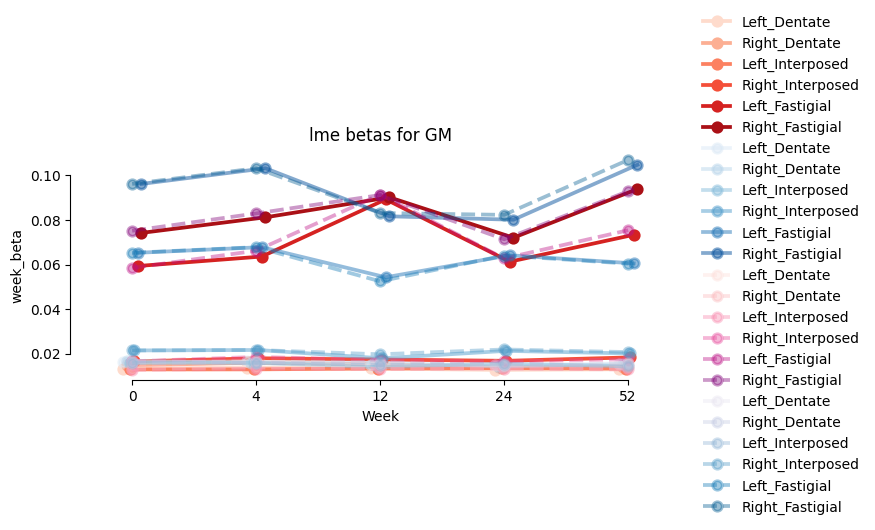

In [5]:
fig, ax = plt.subplots(figsize=(8,3))

sns.pointplot(data = patients_lme, x = 'Week', y = 'week_beta', hue = 'regionname', palette = reds, alpha = 1, dodge = True)
sns.pointplot(data = controls_lme, x = 'Week', y = 'week_beta', hue = 'regionname', palette = blues, alpha = 0.5, dodge = True)

sns.pointplot(data = patients_actual, x = 'Week', y = 'mean', hue = 'regionname', palette = red_purples, alpha = 0.4, linestyle = '--')
sns.pointplot(data = controls_actual, x = 'Week', y = 'mean', hue = 'regionname', palette = blue_purples, alpha = 0.4, linestyle = '--')


ax.set_title(f"lme betas for {segment}")
ax.legend(bbox_to_anchor=(1, .5), loc = 'center left', frameon = False)

sns.despine(trim = True)
plt.show()

## T1

In [6]:
# currently avaialble: 'WM_mod', 'T1'
segment = 'T1'

patients_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_patients_MNISymC_Diedrichsen_2009_{segment}_mean.tsv'), sep = '\t')
controls_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_controls_MNISymC_Diedrichsen_2009_{segment}_mean.tsv'), sep = '\t')

patients_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'patients_MNISymC_{segment}_Diedrichsen_2009_lme.tsv'), sep = '\t')
controls_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'controls_MNISymC_{segment}_Diedrichsen_2009_lme.tsv'), sep = '\t')


patients_lme = patients_lme[patients_lme.regionname.isin(regions)]
controls_lme = controls_lme[controls_lme.regionname.isin(regions)]

patients_actual = patients_actual[patients_actual.regionname.isin(regions)]
controls_actual = controls_actual[controls_actual.regionname.isin(regions)]

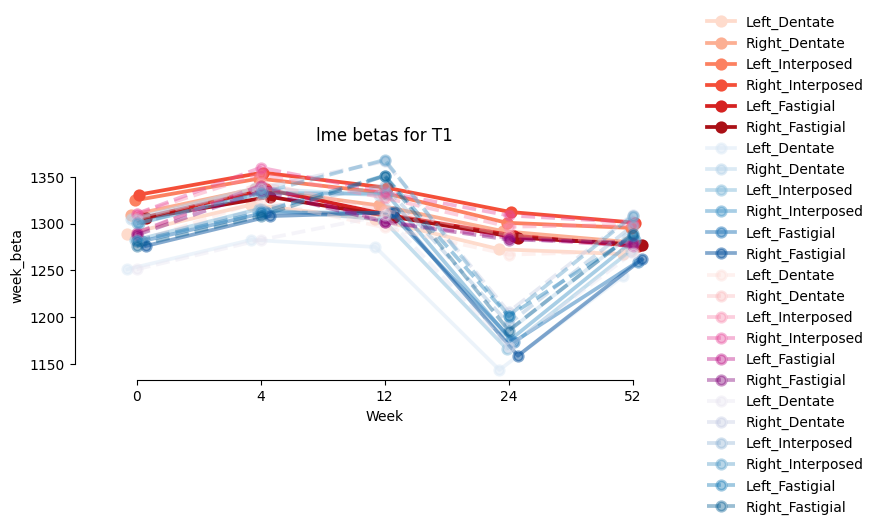

In [7]:
fig, ax = plt.subplots(figsize=(8,3))

sns.pointplot(data = patients_lme, x = 'Week', y = 'week_beta', hue = 'regionname', palette = reds, alpha = 1, dodge = True)
sns.pointplot(data = controls_lme, x = 'Week', y = 'week_beta', hue = 'regionname', palette = blues, alpha = 0.5, dodge = True)

sns.pointplot(data = patients_actual, x = 'Week', y = 'mean', hue = 'regionname', palette = red_purples, alpha = 0.4, linestyle = '--')
sns.pointplot(data = controls_actual, x = 'Week', y = 'mean', hue = 'regionname', palette = blue_purples, alpha = 0.4, linestyle = '--')


ax.set_title(f"lme betas for {segment}")
ax.legend(bbox_to_anchor=(1, .5), loc = 'center left', frameon = False)

sns.despine(trim = True)
plt.show()